In [296]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [297]:
image = cv2.imread('sar_2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

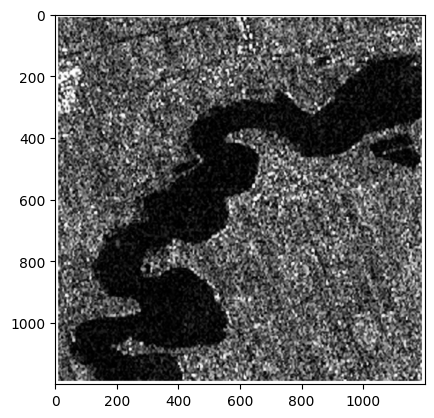

In [298]:
plt.imshow(image_gray, cmap="gray")

# Точечная бинаризация

In [299]:
import copy

bin_img = copy.deepcopy(image_gray)
T  = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

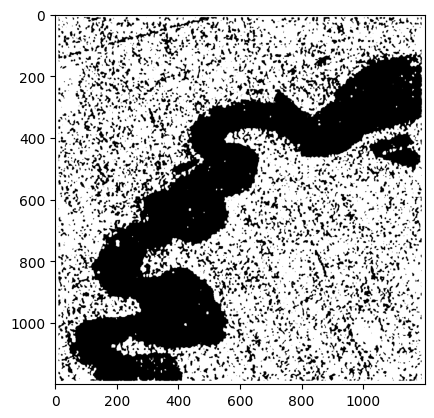

In [300]:
plt.imshow(bin_img, cmap="gray")

# Бинаризация Отсу

In [301]:
# otsu binarization
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

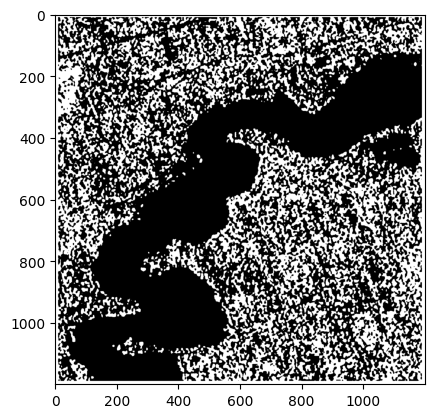

In [302]:
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

In [303]:
# 
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)


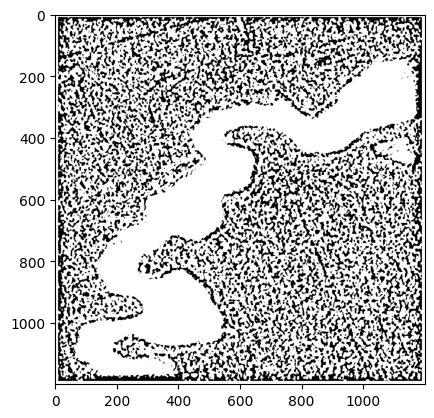

In [304]:
plt.imshow(th3, cmap="gray")

# Оператор Собеля

In [305]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

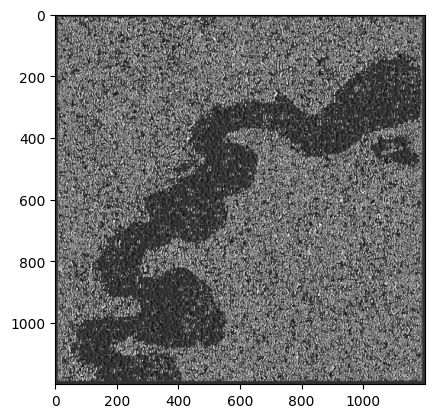

In [306]:
plt.imshow((grad_x - grad_x.min())*255, cmap="gray")

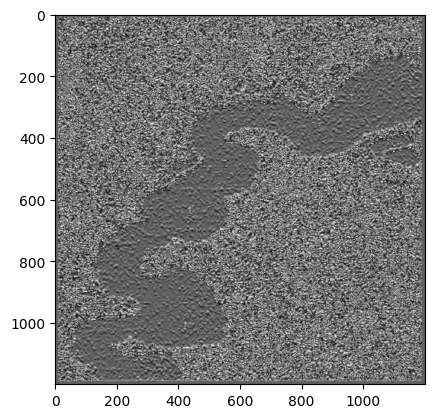

In [307]:
plt.imshow((grad_y - grad_y.min())*255, cmap="gray")

In [308]:
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0) # mean value between

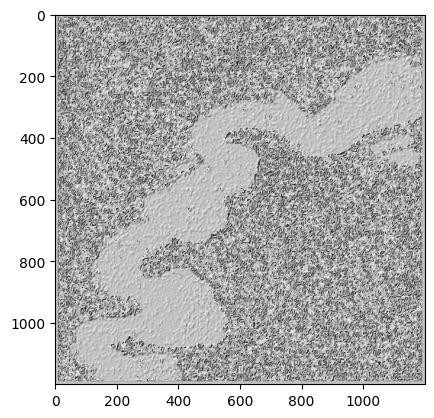

In [309]:
plt.imshow((grad - grad.min())*255, cmap="gray")

# Canny

In [310]:
edges = cv2.Canny(image_gray,100,200)

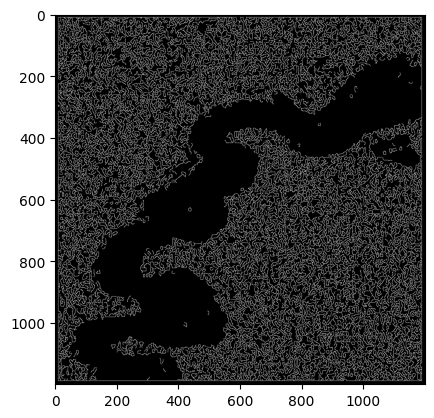

In [311]:
plt.imshow(edges, cmap="gray")

# Преобразование Хафа

In [312]:
image = cv2.imread('img_1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

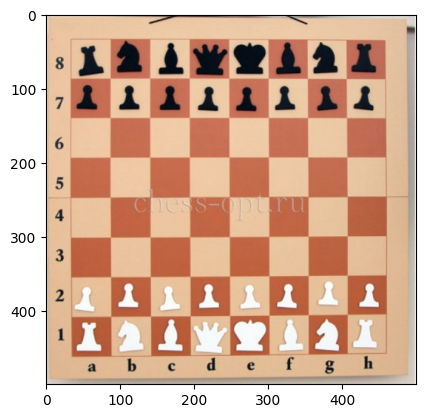

In [313]:
plt.imshow(image)

In [314]:
canny = cv2.Canny(image_gray,50,150,apertureSize = 3)

In [315]:
lines = cv2.HoughLines(canny, 1, np.pi / 180, 190)

In [316]:
import math 

if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(image, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

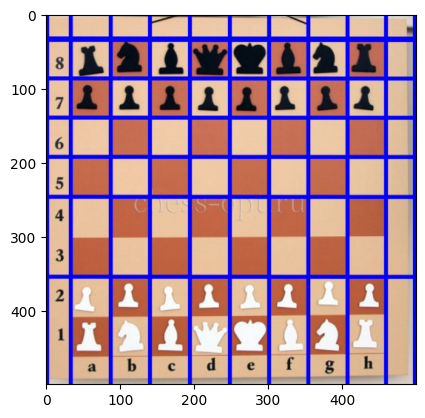

In [317]:
plt.imshow(image)

In [318]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

 ### 1. Для изображения sar_3.jpg найти наиболее протяженный участок 

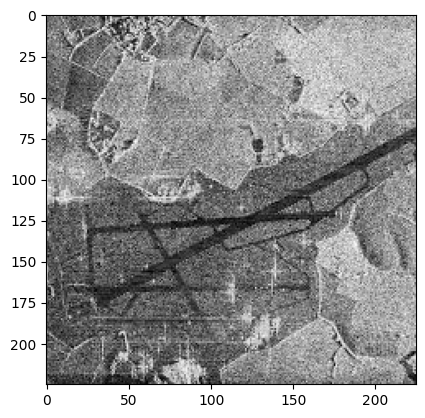

In [319]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image)

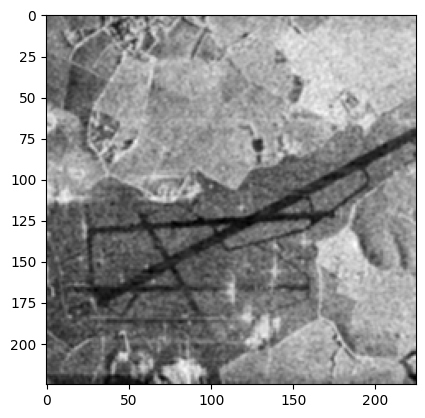

In [320]:
# Для уменьшения влияния шумов
blurred = cv2.GaussianBlur(image_gray, (3, 3), 0)
plt.imshow(blurred, cmap="gray")

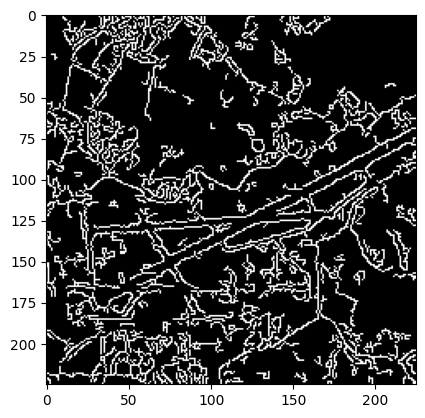

In [321]:
# Выделение границ
edges = cv2.Canny(blurred, 100, 200)
plt.imshow(edges, cmap="gray")

In [322]:
# Поиск самой длинной линии
lines = cv2.HoughLinesP(
    edges,
    rho=1,              # Точность расстояния в 1 пиксель
    theta=np.pi/360,    # Точность угла 0.5 градуса (π/360 радиан)
    threshold=30,       # Порог голосования: минимум 30 точек для линии
    minLineLength=50,   # Минимальная длина отрезка (50 пикселей)
    maxLineGap=10       # Макс. разрыв для объединения отрезков (10 пикселей)
)

image_with_lines = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
longest_line = None
max_length = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        if length > max_length:
            max_length = length
            longest_line = (x1, y1, x2, y2)

if longest_line is not None:
    cv2.line(image_with_lines, longest_line[:2], longest_line[2:], (0, 0, 255), 2)

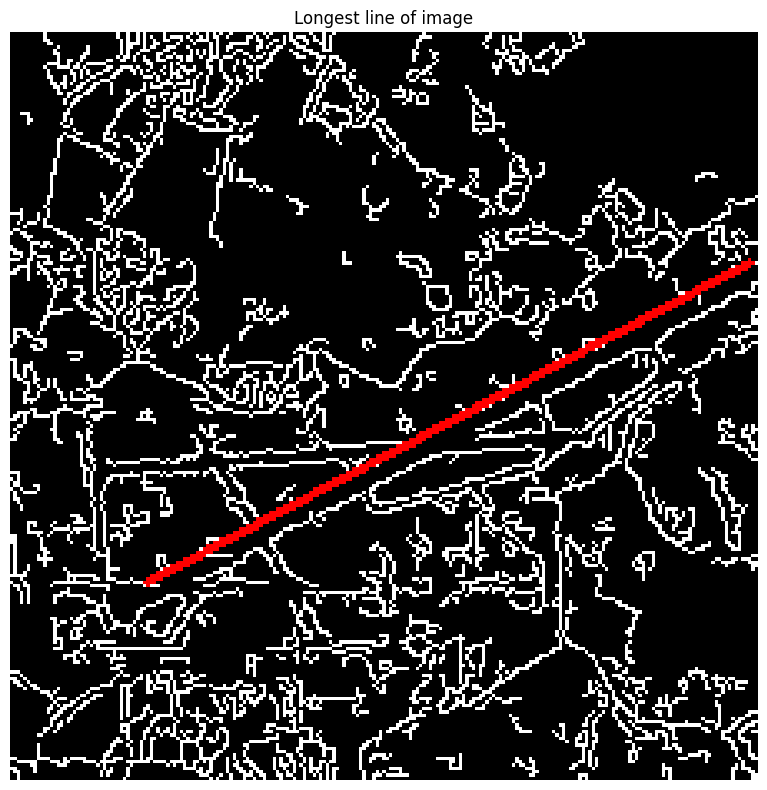

In [323]:
# Визуализация результатов
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image_with_lines, cv2.COLOR_BGR2RGB))
plt.title('Longest line of image')
plt.axis('off')
plt.tight_layout()
plt.show()

 ### 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

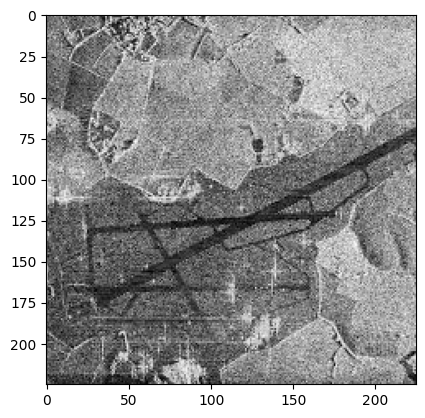

In [324]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image)

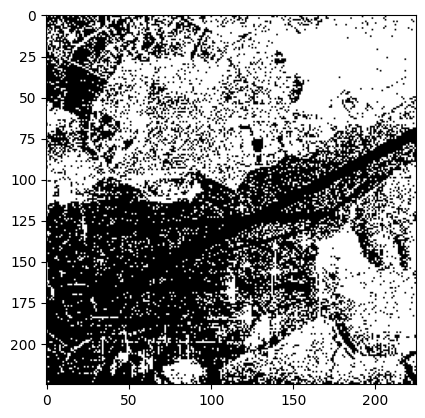

In [ ]:
# Бинаризация методом Оцу
_, otsu_thresh = cv2.threshold(image_gray,
    0,      # пороговое значение
    100,    # максимальное значение для пикселей, превышающих порог (белый цвет)
    cv2.THRESH_BINARY + cv2.THRESH_OTSU  # тип бинаризации: бинарная + автоматический выбор порога по Оцу
)

plt.imshow(otsu_thresh, cmap="gray")

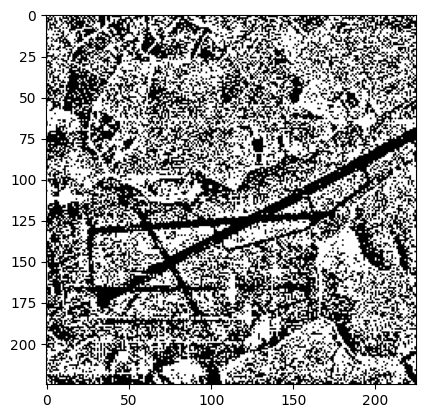

In [ ]:
# Адаптивная бинаризация
adaptive_thresh = cv2.adaptiveThreshold(image_gray,
    255,    # максимальное значение для пикселей, превышающих порог (белый цвет)
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # метод адаптации: взвешенное среднее по Гауссу
    cv2.THRESH_BINARY,  # тип бинаризации: бинарная (белый/черный)
    61,     # размер окрестности для вычисления порога
    3       # константа, вычитаемая из вычисленного порога (регулирует чувствительность)
)

plt.imshow(adaptive_thresh, cmap="gray")

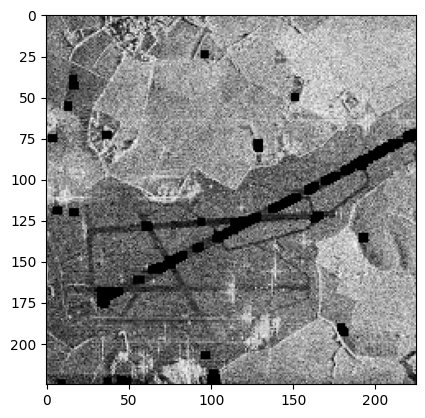

In [327]:
# Обработка бинарной маски
kernel = np.ones((5, 5), np.uint8)
processed_binary = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_CLOSE, kernel)

# Извлечение сегмента дороги
road_segment = cv2.bitwise_and(image, image, mask=processed_binary)

plt.imshow(road_segment, cmap="gray")